# Model Analysis
Loads results from `outputs/results.json` (produced by `python -m main`) and visualizes the full model comparison, the regularization sweeps, and the final conclusion.

In [1]:
import sys
sys.path.append("..")

import matplotlib.pyplot as plt
import numpy as np

from src.save_results import load_results

%matplotlib inline

results = load_results("../outputs/results.json")
results

{'naive_mse': 0.0002480684107334671,
 'ridge_single_split_mse': 0.0002547779903946758,
 'ridge_best_lambda': 0.01,
 'lasso_single_split_mse': 0.00024794052972496484,
 'lasso_best_lambda': 0.001,
 'ridge_walk_forward_avg_mse': 0.000397611075941852,
 'arima_multistep_avg_mse': 0.01588898010024022,
 'arima_rolling_avg_mse': 0.0007755730461377759,
 'garch_vs_squared_returns_mse': 3.922153939876546e-07,
 'gjr_garch_t_weekly_refit_mse': 0.005713973201420477,
 'ridge_lambda_sweep': {'0.0': 0.0002661392850087192,
  '0.001': 0.0002603976323686304,
  '0.01': 0.0002547779903946758,
  '0.1': 0.00031703030515483103,
  '1.0': 0.0005988155693155834},
 'lasso_lambda_sweep': {'0.0': 0.0002661392850087192,
  '0.001': 0.00024794052972496484,
  '0.01': 0.00024876809053904763,
  '0.1': 0.002009327901830037,
  '1.0': 0.2603476415270867},
 'config': {'n_lags': 5,
  'include_volume': True,
  'lambdas_tested': [0.0, 0.001, 0.01, 0.1, 1.0],
  'n_splits': 5,
  'arima_order': [1, 0, 1],
  'garch_refit_every': 5},

## 1. Final comparison across every model tried

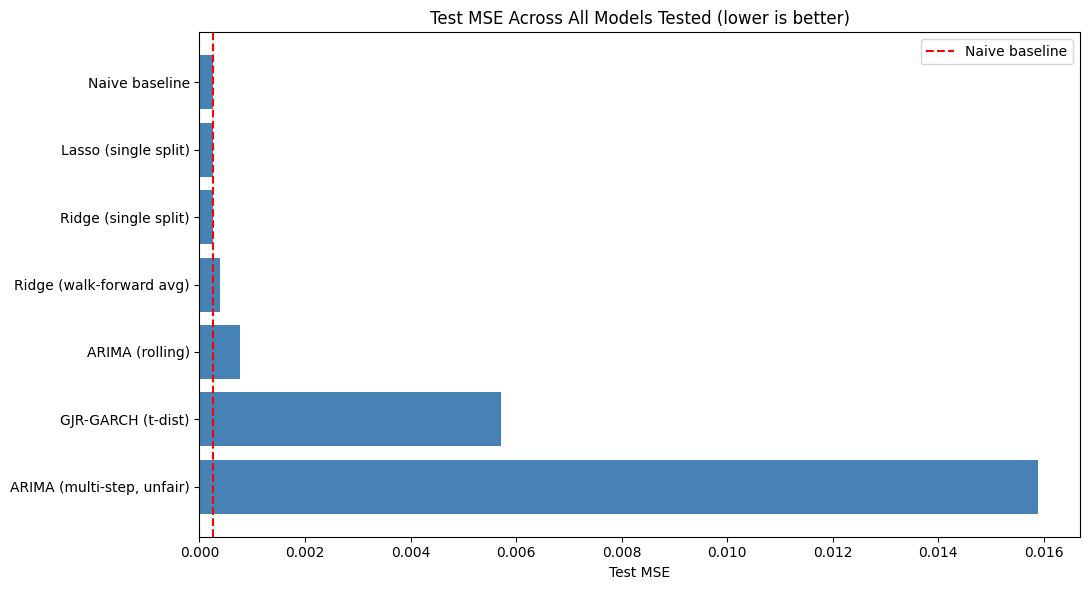

In [2]:
methods = [
    ("Naive baseline", results["naive_mse"]),
    ("Lasso (single split)", results["lasso_single_split_mse"]),
    ("Ridge (single split)", results["ridge_single_split_mse"]),
    ("Ridge (walk-forward avg)", results["ridge_walk_forward_avg_mse"]),
    ("ARIMA (rolling)", results["arima_rolling_avg_mse"]),
    ("GJR-GARCH (t-dist)", results["gjr_garch_t_weekly_refit_mse"]),
    ("ARIMA (multi-step, unfair)", results["arima_multistep_avg_mse"]),
]

names = [m[0] for m in methods]
values = [m[1] for m in methods]

fig, ax = plt.subplots(figsize=(11, 6))
colors = ["steelblue"] * len(methods)
bars = ax.barh(names, values, color=colors)
ax.axvline(results["naive_mse"], color="red", linestyle="--", label="Naive baseline")
ax.set_xlabel("Test MSE")
ax.set_title("Test MSE Across All Models Tested (lower is better)")
ax.invert_yaxis()
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/plots/final_comparison.png", dpi=150)
plt.show()

Every model sits to the right of the naive baseline's red line — meaning every single one had a higher (worse) test MSE than simply assuming tomorrow looks like today. The bars are also roughly ordered by model complexity, which is the core finding of this project.

## 2. Ridge and Lasso lambda sweeps

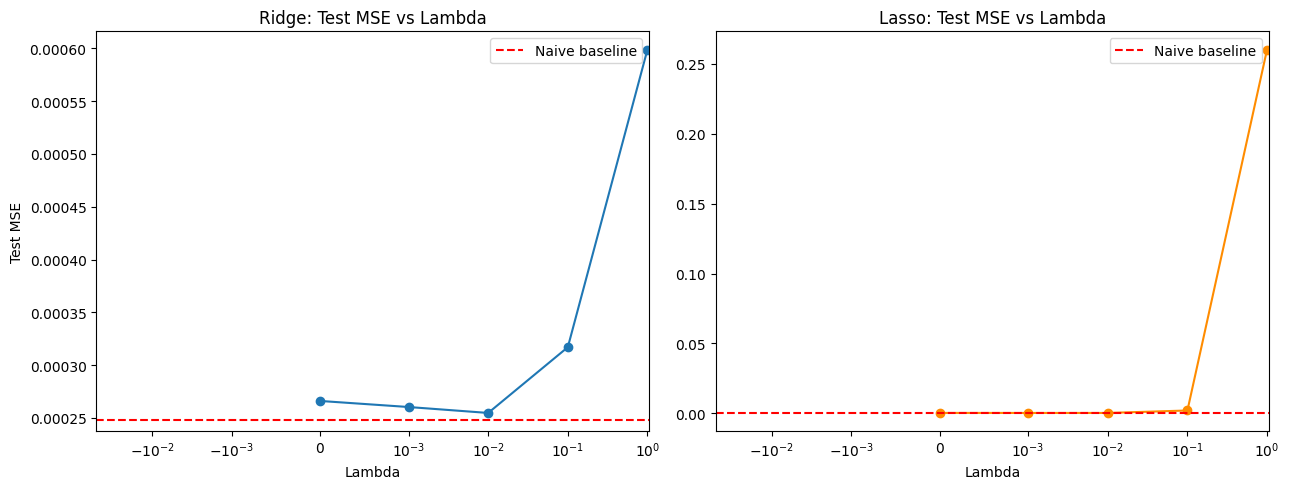

In [3]:
ridge_sweep = results["ridge_lambda_sweep"]
lasso_sweep = results["lasso_lambda_sweep"]

lambdas_r = [float(k) for k in ridge_sweep.keys()]
mse_r = list(ridge_sweep.values())
lambdas_l = [float(k) for k in lasso_sweep.keys()]
mse_l = list(lasso_sweep.values())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(lambdas_r, mse_r, marker="o")
axes[0].axhline(results["naive_mse"], color="red", linestyle="--", label="Naive baseline")
axes[0].set_xscale("symlog", linthresh=0.001)
axes[0].set_title("Ridge: Test MSE vs Lambda")
axes[0].set_xlabel("Lambda")
axes[0].set_ylabel("Test MSE")
axes[0].legend()

axes[1].plot(lambdas_l, mse_l, marker="o", color="darkorange")
axes[1].axhline(results["naive_mse"], color="red", linestyle="--", label="Naive baseline")
axes[1].set_xscale("symlog", linthresh=0.001)
axes[1].set_title("Lasso: Test MSE vs Lambda")
axes[1].set_xlabel("Lambda")
axes[1].legend()

plt.tight_layout()
plt.savefig("../outputs/plots/lambda_sweeps.png", dpi=150)
plt.show()

The bias-variance tradeoff, visible directly: both curves dip to a minimum at a small positive lambda, then rise sharply as regularization gets too strong. Lasso's rise is much sharper past its minimum, since its penalty pushes weights to exactly zero rather than just shrinking them.

## 3. Predicted vs actual volatility (best model)

Data saved to /Users/mav/Quant Projects/stock-volatility-predictor/data/raw/sp500_raw.csv
Epoch 0, Loss: 0.034773
Epoch 1000, Loss: 0.000482
Epoch 2000, Loss: 0.000482
Epoch 3000, Loss: 0.000482
Epoch 4000, Loss: 0.000482


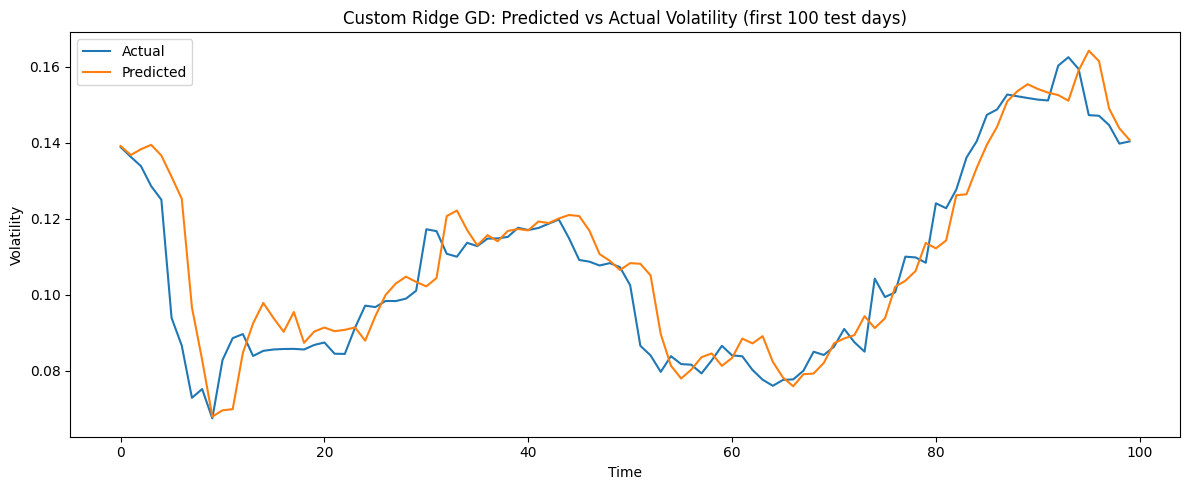

In [4]:
# Re-run the trained model to get predictions for plotting, using the same config as main.py
from src.data_loader import get_data
from src.features import prepare_dataset
from src.model import gradient_descent, predict
from src import config
import numpy as np

df = get_data(ticker=config.TICKER, start=config.START_DATE, end=config.END_DATE)
X, y, df_final = prepare_dataset(df, n_lags=config.N_LAGS, include_volume=config.INCLUDE_VOLUME)
X = np.asarray(X, dtype=np.float64)
y = np.asarray(y, dtype=np.float64)

split = int(config.TRAIN_TEST_SPLIT_RATIO * len(X))
X_train_raw, X_test_raw = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

X_mean, X_std = X_train_raw.mean(axis=0), X_train_raw.std(axis=0)
X_train = (X_train_raw - X_mean) / X_std
X_test = (X_test_raw - X_mean) / X_std

w, b, _ = gradient_descent(X_train, y_train, lr=config.LEARNING_RATE, epochs=config.EPOCHS,
                            lambda_=results["ridge_best_lambda"])
y_pred = predict(X_test, w, b)

plt.figure(figsize=(12, 5))
plt.plot(y_test[:100], label="Actual")
plt.plot(y_pred[:100], label="Predicted")
plt.title("Custom Ridge GD: Predicted vs Actual Volatility (first 100 test days)")
plt.xlabel("Time")
plt.ylabel("Volatility")
plt.legend()
plt.tight_layout()
plt.savefig("../outputs/plots/pred_vs_actual.png", dpi=150)
plt.show()

## 4. Conclusion

None of the models tested — Ridge, Lasso, ARIMA (rolling one-step), GARCH, or GJR-GARCH — beat the naive baseline of assuming tomorrow's volatility equals today's. Error increased roughly monotonically with model complexity, suggesting that on this dataset and time period, additional parameters added estimation noise faster than they captured genuine signal. See the project README for the full narrative and the specific bugs/methodology issues (a loss-scaling mismatch vs sklearn, an unfair multi-step ARIMA evaluation) found and fixed along the way.